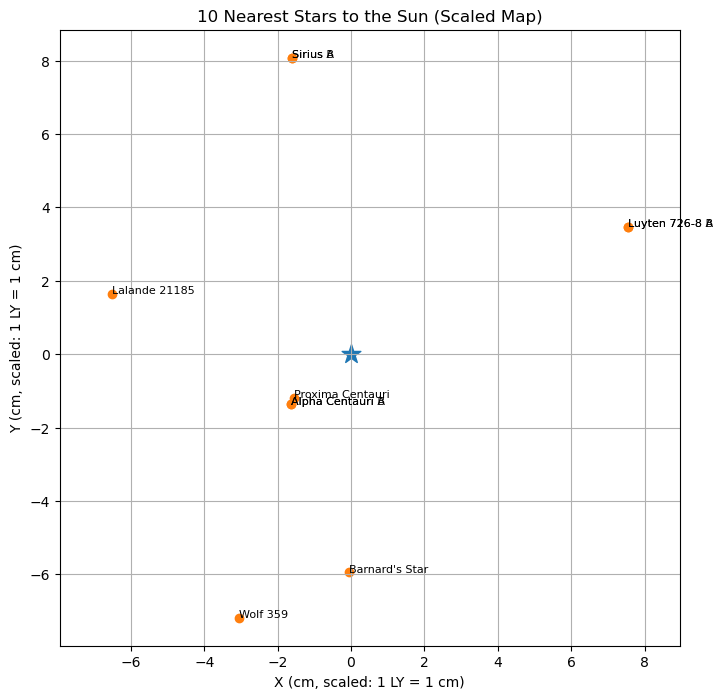

In [1]:
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
import numpy as np

# -------------------------------
# 1. Define 10 nearest stars
# -------------------------------
names = [
    "Proxima Centauri", "Alpha Centauri A", "Alpha Centauri B",
    "Barnard's Star", "Wolf 359", "Lalande 21185",
    "Sirius A", "Sirius B", "Luyten 726-8 A", "Luyten 726-8 B"
]

# RA (deg), Dec (deg), Distance (light years)
ra = [217.4292, 219.9021, 219.9021, 269.4521, 247.0333, 165.8342,
      101.2875, 101.2875, 24.7533, 24.7533]

dec = [-62.6795, -60.8339, -60.8339, 4.6934, 7.0147, 35.9700,
       -16.7161, -16.7161, -17.9559, -17.9559]

distance_ly = [4.24, 4.37, 4.37, 5.96, 7.86, 8.31,
               8.60, 8.60, 8.73, 8.73]

# -------------------------------
# 2. Create SkyCoord object
# -------------------------------
coords = SkyCoord(
    ra=ra * u.degree,
    dec=dec * u.degree,
    distance=distance_ly * u.lightyear
)

# -------------------------------
# 3. Convert to Cartesian coords
# -------------------------------
cartesian = coords.cartesian

x = cartesian.x.to(u.lightyear).value
y = cartesian.y.to(u.lightyear).value
z = cartesian.z.to(u.lightyear).value

# -------------------------------
# 4. Apply scale: 1 LY = 1 cm
# -------------------------------
# So numerical values stay same, but interpreted as cm
x_scaled = x
y_scaled = y

# -------------------------------
# 5. Plot (2D projection)
# -------------------------------
plt.figure(figsize=(8, 8))

plt.scatter(0, 0, marker='*', s=200)  # Sun at origin

plt.scatter(x_scaled, y_scaled)

# Annotate stars
for i, name in enumerate(names):
    plt.text(x_scaled[i], y_scaled[i], name, fontsize=8)

plt.xlabel("X (cm, scaled: 1 LY = 1 cm)")
plt.ylabel("Y (cm, scaled: 1 LY = 1 cm)")
plt.title("10 Nearest Stars to the Sun (Scaled Map)")

plt.grid()
plt.axis('equal')

plt.show()